# Airscope tube test dataset Visualization and Analysis

This notebook provides comprehensive visualization and analysis of the calcium imaging dataset before training the dual-stream transformer model.

## Overview

We'll analyze:
- Dataset structure and statistics
- PCA preprocessing results
- Trial length distributions
- Label balance
- Sample neural activity patterns
- Data quality metrics

---

In [1]:
import os.path
import pickle
import re
import random
from datetime import datetime
from tqdm import tqdm
from functools import partial
from collections import OrderedDict, Counter

# Scientific computing
import numpy as np
import pandas as pd

# Machine learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from dataset import CalciumDataset, CalciumDataset_two_stream
from dataset_augment import CalciumDataset_two_stream_pair_pca

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [2]:
def visualize_dataset(dataset):
    """Create comprehensive visualizations of the dataset"""
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Trial length distribution
    plt.subplot(3, 4, 1)
    plt.hist(dataset.trial_lengths, bins=30, alpha=0.7, edgecolor='black')
    plt.axvline(dataset.seq_length, color='red', linestyle='--', 
                label=f'Target length: {dataset.seq_length}')
    plt.xlabel('Trial Length (frames)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Original Trial Lengths')
    plt.legend()
    
    # 2. Label distribution
    plt.subplot(3, 4, 2)
    label_counts = Counter(dataset.win_labels)
    plt.bar(label_counts.keys(), label_counts.values(), alpha=0.7)
    plt.xlabel('Winner Label')
    plt.ylabel('Count')
    plt.title('Label Distribution')
    plt.xticks([0, 1], ['Mouse 2 Wins', 'Mouse 1 Wins'])
    
    # 3. PCA variance explained
    if dataset.pca_stats:
        plt.subplot(3, 4, 3)
        var_explained = [stat['mouse1_var_explained'] for stat in dataset.pca_stats] + \
                       [stat['mouse2_var_explained'] for stat in dataset.pca_stats]
        plt.hist(var_explained, bins=20, alpha=0.7, edgecolor='black')
        plt.xlabel('PCA Variance Explained')
        plt.ylabel('Frequency')
        plt.title('PCA Variance Explained Distribution')
        
        # 4. Number of neurons per mouse
        plt.subplot(3, 4, 4)
        neuron_counts = [stat['mouse1_neurons'] for stat in dataset.pca_stats] + \
                       [stat['mouse2_neurons'] for stat in dataset.pca_stats]
        plt.hist(neuron_counts, bins=20, alpha=0.7, edgecolor='black')
        plt.xlabel('Number of Neurons')
        plt.ylabel('Frequency')
        plt.title('Neuron Count Distribution')
    
    # 5-8. Sample time series data
    sample_data = dataset.get_sample_data(n_samples=4)
    
    for i, sample in enumerate(sample_data):
        plt.subplot(3, 4, 5 + i)
        
        # Plot first few PCA components
        mouse1_data = sample['mouse1_data'][:, :5]  # First 5 components
        mouse2_data = sample['mouse2_data'][:, :5]  # First 5 components
        
        time_points = np.arange(len(mouse1_data))
        
        # Plot mouse 1 data
        for j in range(mouse1_data.shape[1]):
            plt.plot(time_points, mouse1_data[:, j], 
                    alpha=0.7, linestyle='-', label=f'M1_PC{j+1}' if j < 2 else None)
        
        # Plot mouse 2 data
        for j in range(mouse2_data.shape[1]):
            plt.plot(time_points, mouse2_data[:, j], 
                    alpha=0.7, linestyle='--', label=f'M2_PC{j+1}' if j < 2 else None)
        
        plt.xlabel('Time (frames)')
        plt.ylabel('PCA Component Value')
        plt.title(f'Trial {i+1}: {sample["mouse_pair"]}\nWinner: Mouse {sample["label"]+1}')
        if i == 0:
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 9. Correlation heatmap between first few PCA components
    plt.subplot(3, 4, 9)
    if sample_data:
        # Use first sample for correlation analysis
        combined_data = np.hstack([
            sample_data[0]['mouse1_data'][:, :10],  # First 10 components
            sample_data[0]['mouse2_data'][:, :10]
        ])
        correlation_matrix = np.corrcoef(combined_data.T)
        
        im = plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
        plt.colorbar(im)
        plt.title('PCA Component Correlations\n(First Sample)')
        plt.xlabel('Component Index')
        plt.ylabel('Component Index')
    
    # 10. Data value distribution
    plt.subplot(3, 4, 10)
    all_values = []
    for sample in sample_data:
        all_values.extend(sample['mouse1_data'].flatten())
        all_values.extend(sample['mouse2_data'].flatten())
    
    plt.hist(all_values, bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel('PCA Component Value')
    plt.ylabel('Frequency')
    plt.title('Distribution of PCA Values')
    
    # 11. Trial length vs Label
    plt.subplot(3, 4, 11)
    trial_lengths_by_label = {0: [], 1: []}
    for i, length in enumerate(dataset.trial_lengths):
        if i < len(dataset.win_labels):
            trial_lengths_by_label[dataset.win_labels[i]].append(length)
    
    plt.boxplot([trial_lengths_by_label[0], trial_lengths_by_label[1]], 
                labels=['Mouse 2 Wins', 'Mouse 1 Wins'])
    plt.ylabel('Trial Length (frames)')
    plt.title('Trial Length by Winner')
    
    # 12. Summary statistics
    plt.subplot(3, 4, 12)
    plt.axis('off')
    
    # Calculate summary statistics
    stats_text = f"""Dataset Summary:
    
Total Trials: {len(dataset)}
PCA Dimensions: {dataset.pca_dim}
Target Seq Length: {dataset.seq_length}

Trial Length Stats:
Mean: {np.mean(dataset.trial_lengths):.1f}
Std: {np.std(dataset.trial_lengths):.1f}
Min: {np.min(dataset.trial_lengths)}
Max: {np.max(dataset.trial_lengths)}

Label Balance:
Mouse 1 Wins: {sum(dataset.win_labels)} ({100*sum(dataset.win_labels)/len(dataset.win_labels):.1f}%)
Mouse 2 Wins: {len(dataset.win_labels)-sum(dataset.win_labels)} ({100*(len(dataset.win_labels)-sum(dataset.win_labels))/len(dataset.win_labels):.1f}%)

Augmentation (Training):
Random Crop: {dataset.random_crop}
Channel Shuffle: {dataset.channel_shuffle_prob}
Channel Dropout: {dataset.channel_dropout_prob}
Time Masking: {dataset.time_mask_prob}
"""
    
    plt.text(0.1, 0.9, stats_text, transform=plt.gca().transAxes, 
             fontsize=10, verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    plt.show()

print("Main visualization function defined!")


### Detailed Sequence Visualization

def plot_sample_sequences(dataset, n_samples=3):
    """Plot detailed view of sample sequences"""
    
    sample_data = dataset.get_sample_data(n_samples=n_samples)
    
    fig, axes = plt.subplots(n_samples, 2, figsize=(15, 4*n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, sample in enumerate(sample_data):
        mouse1_data = sample['mouse1_data']
        mouse2_data = sample['mouse2_data']
        
        # Plot mouse 1 data
        ax1 = axes[i, 0]
        im1 = ax1.imshow(mouse1_data.T, aspect='auto', cmap='viridis', interpolation='nearest')
        ax1.set_title(f'Mouse 1 - Trial {i+1}\n{sample["mouse_pair"]} (Length: {sample["trial_length"]})')
        ax1.set_xlabel('Time (frames)')
        ax1.set_ylabel('PCA Component')
        plt.colorbar(im1, ax=ax1)
        
        # Plot mouse 2 data
        ax2 = axes[i, 1]
        im2 = ax2.imshow(mouse2_data.T, aspect='auto', cmap='viridis', interpolation='nearest')
        ax2.set_title(f'Mouse 2 - Trial {i+1}\nWinner: Mouse {sample["label"]+1}')
        ax2.set_xlabel('Time (frames)')
        ax2.set_ylabel('PCA Component')
        plt.colorbar(im2, ax=ax2)
    
    plt.tight_layout()
    plt.show()

print("Sequence visualization function defined!")


### PCA Analysis Function


def analyze_pca_results(dataset):
    """Detailed analysis of PCA preprocessing results"""
    
    if not dataset.pca_stats:
        print("No PCA statistics available!")
        return
    
    # Convert to DataFrame for easier analysis
    pca_df = pd.DataFrame(dataset.pca_stats)
    
    print("=== PCA Analysis Results ===\n")
    
    # Summary statistics
    print("Variance Explained Summary:")
    print(f"Mouse 1 - Mean: {pca_df['mouse1_var_explained'].mean():.4f}, Std: {pca_df['mouse1_var_explained'].std():.4f}")
    print(f"Mouse 2 - Mean: {pca_df['mouse2_var_explained'].mean():.4f}, Std: {pca_df['mouse2_var_explained'].std():.4f}")
    
    print(f"\nNeuron Count Summary:")
    print(f"Mouse 1 - Mean: {pca_df['mouse1_neurons'].mean():.1f}, Range: [{pca_df['mouse1_neurons'].min()}-{pca_df['mouse1_neurons'].max()}]")
    print(f"Mouse 2 - Mean: {pca_df['mouse2_neurons'].mean():.1f}, Range: [{pca_df['mouse2_neurons'].min()}-{pca_df['mouse2_neurons'].max()}]")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Variance explained comparison
    axes[0, 0].scatter(pca_df['mouse1_var_explained'], pca_df['mouse2_var_explained'], alpha=0.7)
    axes[0, 0].plot([0, 1], [0, 1], 'r--', alpha=0.5)
    axes[0, 0].set_xlabel('Mouse 1 Variance Explained')
    axes[0, 0].set_ylabel('Mouse 2 Variance Explained')
    axes[0, 0].set_title('PCA Variance Explained Comparison')
    
    # Neuron count comparison
    axes[0, 1].scatter(pca_df['mouse1_neurons'], pca_df['mouse2_neurons'], alpha=0.7)
    axes[0, 1].set_xlabel('Mouse 1 Neuron Count')
    axes[0, 1].set_ylabel('Mouse 2 Neuron Count')
    axes[0, 1].set_title('Neuron Count Comparison')
    
    # Variance vs neuron count
    axes[1, 0].scatter(pca_df['mouse1_neurons'], pca_df['mouse1_var_explained'], alpha=0.7, label='Mouse 1')
    axes[1, 0].scatter(pca_df['mouse2_neurons'], pca_df['mouse2_var_explained'], alpha=0.7, label='Mouse 2')
    axes[1, 0].set_xlabel('Neuron Count')
    axes[1, 0].set_ylabel('Variance Explained')
    axes[1, 0].set_title('Neuron Count vs PCA Performance')
    axes[1, 0].legend()
    
    # Mouse pair summary
    axes[1, 1].axis('off')
    summary_text = f"""PCA Summary:

Total Mouse Pairs: {len(pca_df)}
PCA Dimensions: {dataset.pca_dim}

Variance Explained:
- Best: {max(pca_df['mouse1_var_explained'].max(), pca_df['mouse2_var_explained'].max()):.4f}
- Worst: {min(pca_df['mouse1_var_explained'].min(), pca_df['mouse2_var_explained'].min()):.4f}

Neuron Counts:
- Max: {max(pca_df['mouse1_neurons'].max(), pca_df['mouse2_neurons'].max())}
- Min: {min(pca_df['mouse1_neurons'].min(), pca_df['mouse2_neurons'].min())}

Total Timepoints: {pca_df['total_timepoints'].iloc[0]}
"""
    
    axes[1, 1].text(0.1, 0.9, summary_text, transform=axes[1, 1].transAxes,
                    fontsize=11, verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    plt.show()
    
    return pca_df

print("PCA analysis function defined!")

Main visualization function defined!
Sequence visualization function defined!
PCA analysis function defined!


In [3]:
# Configuration
data_dir = r"D:\BBNC\PICO\code\PICO_figure_plot\tube_test\data"  # Update this path
input_dim = 128  # PCA dimension
seq_length = 196
embed_dim = 128
depth = 1
num_heads = 2
mlp_ratio = 1.0
drop_ratio = 0.2
lr = 1e-3

print("Configuration set!")
print(f"PCA dimensions: {input_dim}")
print(f"Sequence length: {seq_length}")



# Load data dictionaries
print("Loading data files...")

data_paths = [os.path.join(data_dir, tmp) for tmp in os.listdir(data_dir)]
data_dict_list = []

for data_path in data_paths:
    try:
        with open(data_path, "rb") as f:
            data_dict = pickle.load(f)
            data_dict_list.append(data_dict)
        print(f"✓ Loaded: {os.path.basename(data_path)}")
    except Exception as e:
        print(f"✗ Failed to load {os.path.basename(data_path)}: {e}")

print(f"\nSuccessfully loaded {len(data_dict_list)} data files!")



# Create training dataset with full augmentation
print("Creating training dataset...")

train_dataset = CalciumDataset_two_stream_pair_pca(
    data_dict_list,
    seq_length=seq_length,
    pca_dim=input_dim,
    save_path="cache/train_data_integrated_pca_viz.pkl",
    training=True,
    # Augmentation parameters
    random_crop=True,
    channel_shuffle_prob=0.2,
    channel_shuffle_ratio=0.1,
    channel_dropout_prob=0.2,
    channel_dropout_ratio=0.1,
    time_mask_prob=0.2,
    time_mask_ratio=0.1
)

print(f"\n✓ Training dataset created successfully!")
print(f"   Total trials: {len(train_dataset)}")
print(f"   PCA dimensions: {input_dim}")
print(f"   Target sequence length: {seq_length}")

Configuration set!
PCA dimensions: 128
Sequence length: 196
Loading data files...
✓ Loaded: 0620_cage3.pkl
✓ Loaded: 0621_cage2.pkl
✓ Loaded: 0621_cage3.pkl
✓ Loaded: 0622_cage2.pkl

Successfully loaded 4 data files!
Creating training dataset...
Processing data with integrated PCA...


Processing data files:   0%|          | 0/4 [00:00<?, ?it/s]

Mouse pair m1-m2: PCA variance explained - Mouse1: 0.9534, Mouse2: 0.9450
Mouse pair m1-m3: PCA variance explained - Mouse1: 0.7549, Mouse2: 0.9665
Mouse pair m4-m1: PCA variance explained - Mouse1: 0.6780, Mouse2: 0.6841


Processing data files:  25%|██▌       | 1/4 [00:05<00:17,  5.70s/it]

Mouse pair m4-m3: PCA variance explained - Mouse1: 0.9320, Mouse2: 0.9837
Mouse pair m1-m3: PCA variance explained - Mouse1: 0.8423, Mouse2: 0.7596
Mouse pair m2-m4: PCA variance explained - Mouse1: 0.7692, Mouse2: 0.8760


...

Mouse pair m4-m3: PCA variance explained - Mouse1: 0.7686, Mouse2: 0.7065
Mouse pair m1-m2: PCA variance explained - Mouse1: 0.7658, Mouse2: 0.7812


Processing data files:  75%|███████▌  | 3/4 [00:14<00:04,  4.59s/it]

Mouse pair m4-m2: PCA variance explained - Mouse1: 0.8206, Mouse2: 0.8330
Mouse pair m1-m4: PCA variance explained - Mouse1: 0.8253, Mouse2: 0.8404
Mouse pair m2-m1: PCA variance explained - Mouse1: 0.8153, Mouse2: 0.8550
Mouse pair m2-m3: PCA variance explained - Mouse1: 0.6996, Mouse2: 0.7315
Mouse pair m3-m1: PCA variance explained - Mouse1: 0.7384, Mouse2: 0.8050
Mouse pair m3-m4: PCA variance explained - Mouse1: 0.7214, Mouse2: 0.7599


Processing data files: 100%|██████████| 4/4 [00:25<00:00,  6.48s/it]

Mouse pair m4-m2: PCA variance explained - Mouse1: 0.8119, Mouse2: 0.7494
Saving preprocessed data to cache/train_data_integrated_pca_viz.pkl...

✓ Training dataset created successfully!
   Total trials: 86
   PCA dimensions: 128
   Target sequence length: 196


### Main Overview Dashboard

Generating comprehensive dataset visualization...


C:\Users\TSingSV\AppData\Local\Temp\ipykernel_2116\1307775681.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([trial_lengths_by_label[0], trial_lengths_by_label[1]],


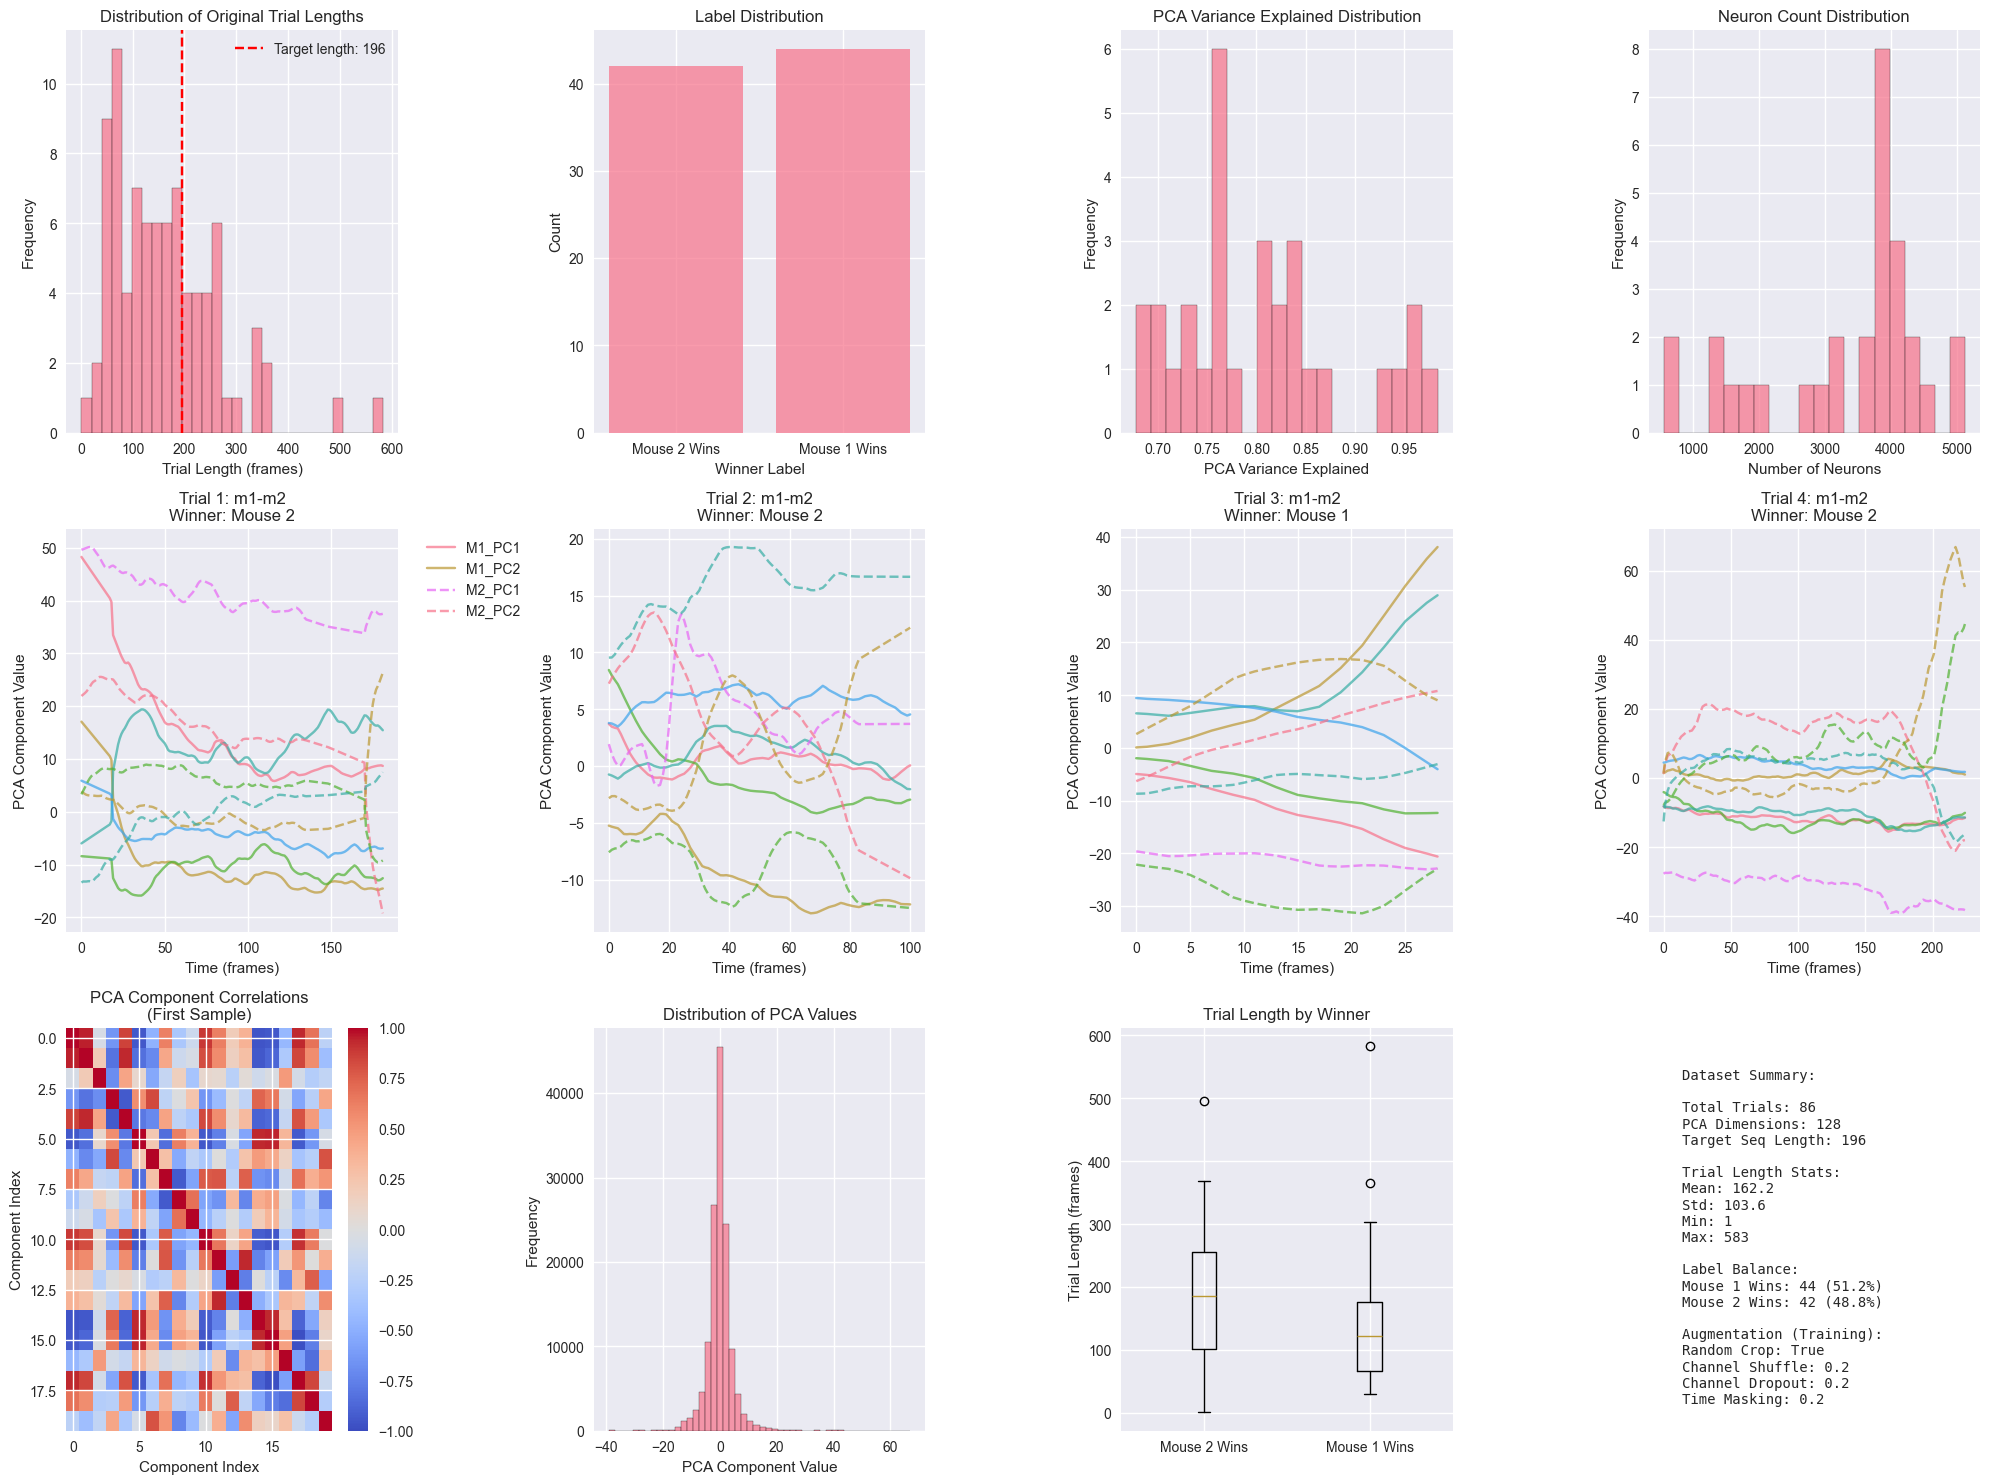

In [4]:
print("Generating comprehensive dataset visualization...")
visualize_dataset(train_dataset)

### Detailed Sequence Analysis

Generating detailed sequence visualizations...


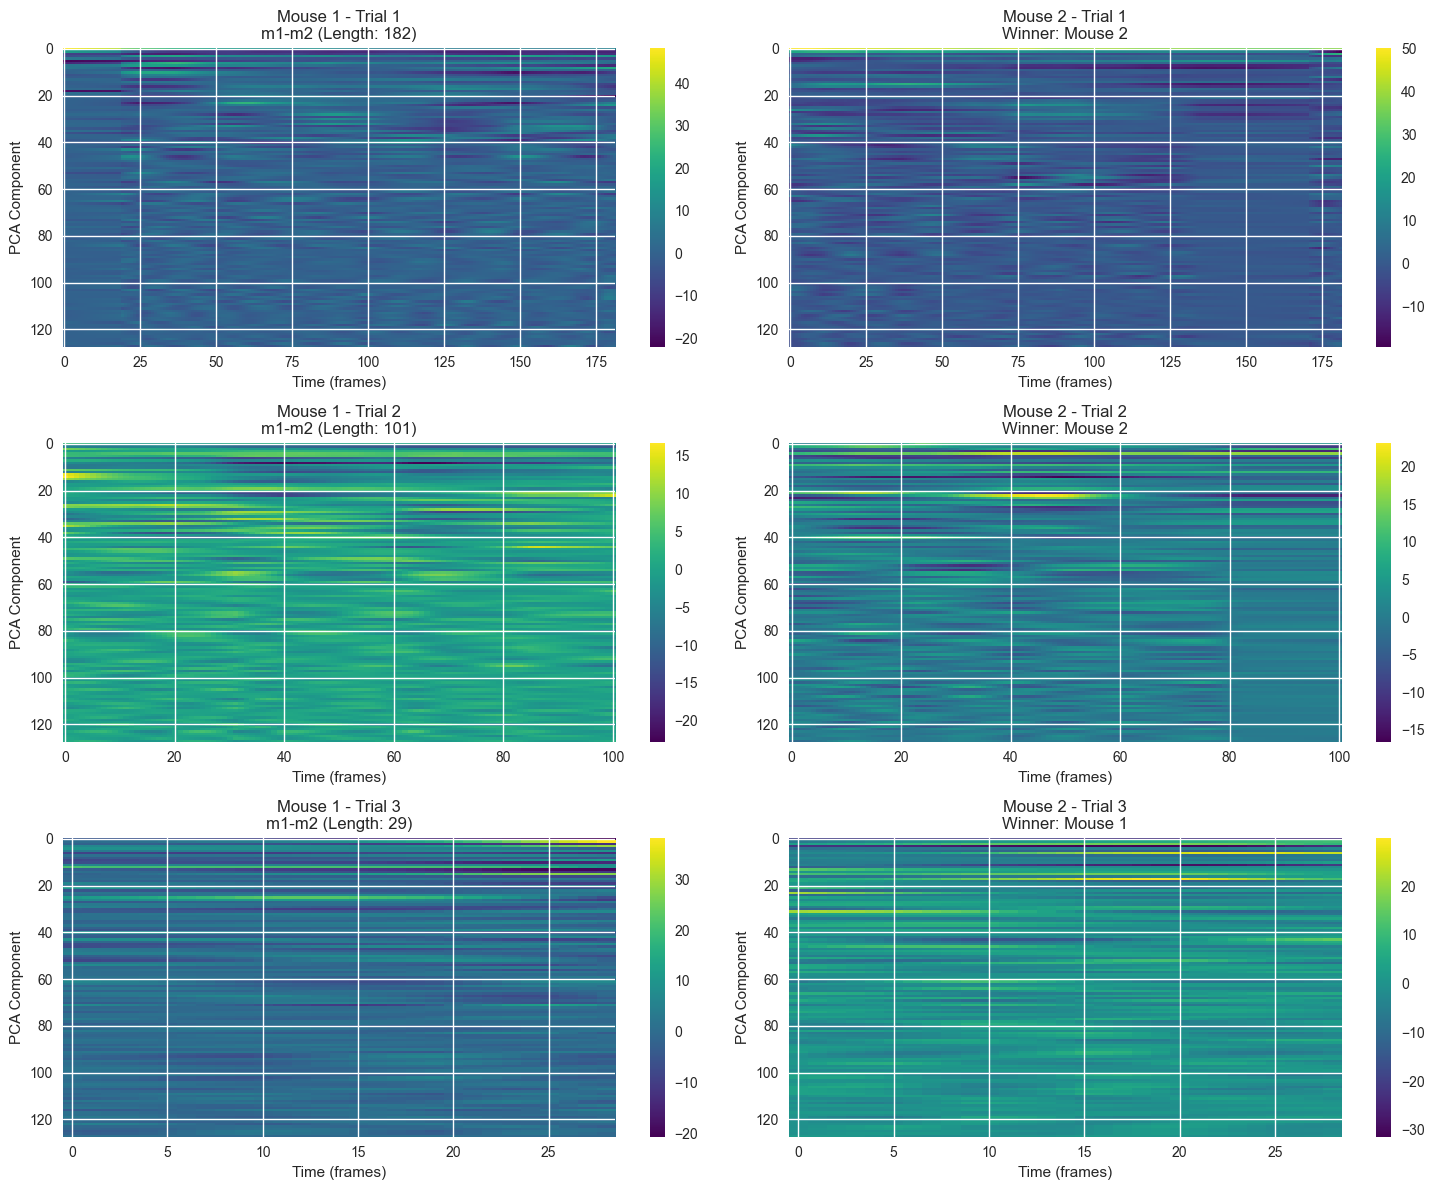

In [5]:
print("Generating detailed sequence visualizations...")
plot_sample_sequences(train_dataset, n_samples=3)

### PCA Preprocessing Analysis

Analyzing PCA preprocessing results...
=== PCA Analysis Results ===

Variance Explained Summary:
Mouse 1 - Mean: 0.7931, Std: 0.0772
Mouse 2 - Mean: 0.8184, Std: 0.0933

Neuron Count Summary:
Mouse 1 - Mean: 3184.7, Range: [1394-4974]
Mouse 2 - Mean: 3459.7, Range: [559-5125]


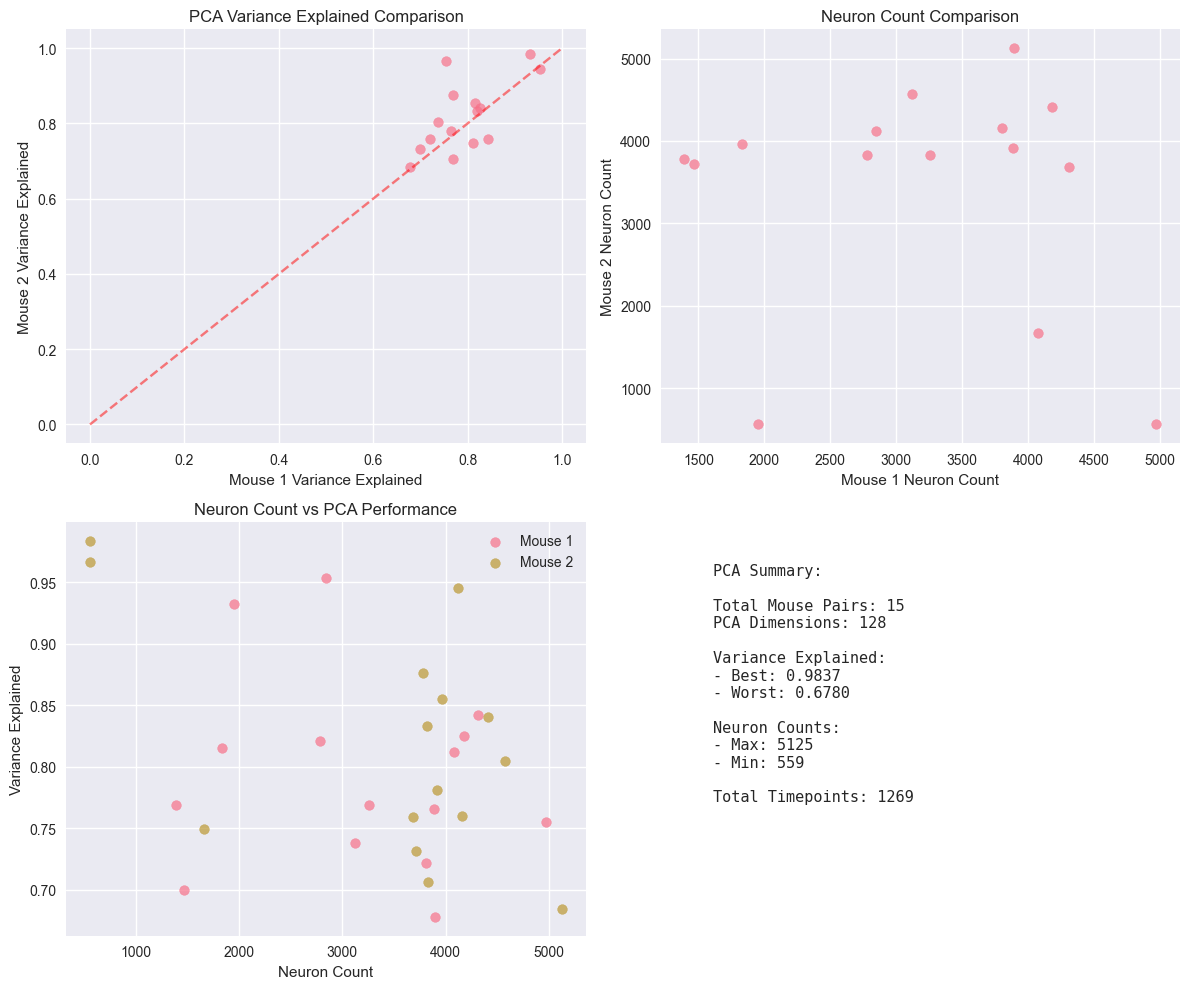


PCA Statistics DataFrame:


,mouse_pair,mouse1_neurons,mouse2_neurons,mouse1_var_explained,mouse2_var_explained,total_timepoints
0,m1-m2,2847,4120,0.953384,0.944972,1269
1,m1-m3,4974,559,0.754931,0.966472,4852
2,m4-m1,3893,5125,0.677982,0.684110,7480
3,m4-m3,1949,559,0.931983,0.983741,1796
4,m1-m3,4308,3686,0.842349,0.759584,4279


In [6]:
print("Analyzing PCA preprocessing results...")
pca_results = analyze_pca_results(train_dataset)

# Display the PCA statistics DataFrame
if pca_results is not None:
    print("\nPCA Statistics DataFrame:")
    display(pca_results.head())


In [7]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

print("Analyzing first training batch...")

# Analyze first batch
for batch_idx, batch in enumerate(train_loader):
    mouse1_data, mouse2_data, mouse1_mask, mouse2_mask, labels = batch
    
    print(f"\nBatch {batch_idx + 1} Analysis:")
    print(f"  Batch size: {len(labels)}")
    print(f"  Mouse1 data shape: {mouse1_data.shape}")
    print(f"  Mouse2 data shape: {mouse2_data.shape}")
    print(f"  Mouse1 mask shape: {mouse1_mask.shape}")
    print(f"  Mouse2 mask shape: {mouse2_mask.shape}")
    print(f"  Labels shape: {labels.shape}")
    
    # Data statistics
    print(f"\nData Statistics:")
    print(f"  Mouse1 data range: [{mouse1_data.min():.3f}, {mouse1_data.max():.3f}]")
    print(f"  Mouse2 data range: [{mouse2_data.min():.3f}, {mouse2_data.max():.3f}]")
    print(f"  Mouse1 mask coverage: {mouse1_mask.float().mean():.3f}")
    print(f"  Mouse2 mask coverage: {mouse2_mask.float().mean():.3f}")
    
    # Label distribution
    label_counts = torch.bincount(labels)
    print(f"\nLabel Distribution in Batch:")
    print(f"  Mouse 2 wins (label 0): {label_counts[0] if len(label_counts) > 0 else 0}")
    print(f"  Mouse 1 wins (label 1): {label_counts[1] if len(label_counts) > 1 else 0}")
    
    break  # Only analyze first batch

Analyzing first training batch...

Batch 1 Analysis:
  Batch size: 32
  Mouse1 data shape: torch.Size([32, 196, 128])
  Mouse2 data shape: torch.Size([32, 196, 128])
  Mouse1 mask shape: torch.Size([32, 196])
  Mouse2 mask shape: torch.Size([32, 196])
  Labels shape: torch.Size([32])

Data Statistics:
  Mouse1 data range: [-39.159, 66.566]
  Mouse2 data range: [-35.776, 74.687]
  Mouse1 mask coverage: 0.729
  Mouse2 mask coverage: 0.729

Label Distribution in Batch:
  Mouse 2 wins (label 0): 12
  Mouse 1 wins (label 1): 20


Analyzing multiple batches...


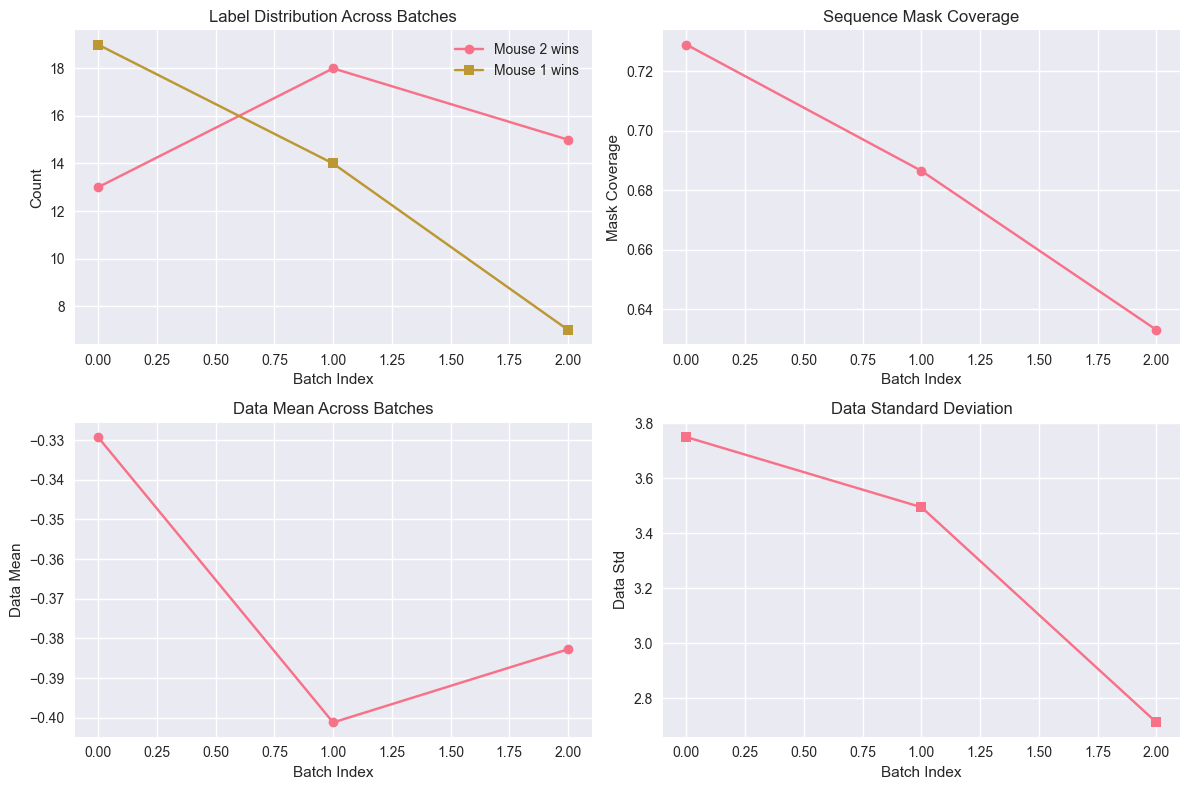

In [8]:
def plot_batch_analysis(data_loader, n_batches=5):
    """Analyze multiple batches for consistency"""
    
    batch_stats = {
        'batch_idx': [],
        'label_0_count': [],
        'label_1_count': [],
        'mask_coverage': [],
        'data_mean': [],
        'data_std': []
    }
    
    for batch_idx, batch in enumerate(data_loader):
        if batch_idx >= n_batches:
            break
            
        mouse1_data, mouse2_data, mouse1_mask, mouse2_mask, labels = batch
        
        # Collect statistics
        batch_stats['batch_idx'].append(batch_idx)
        
        label_counts = torch.bincount(labels, minlength=2)
        batch_stats['label_0_count'].append(label_counts[0].item())
        batch_stats['label_1_count'].append(label_counts[1].item())
        
        batch_stats['mask_coverage'].append(mouse1_mask.float().mean().item())
        batch_stats['data_mean'].append(mouse1_data.mean().item())
        batch_stats['data_std'].append(mouse1_data.std().item())
    
    # Plot results
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Label distribution across batches
    axes[0, 0].plot(batch_stats['batch_idx'], batch_stats['label_0_count'], 'o-', label='Mouse 2 wins')
    axes[0, 0].plot(batch_stats['batch_idx'], batch_stats['label_1_count'], 's-', label='Mouse 1 wins')
    axes[0, 0].set_xlabel('Batch Index')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Label Distribution Across Batches')
    axes[0, 0].legend()
    
    # Mask coverage
    axes[0, 1].plot(batch_stats['batch_idx'], batch_stats['mask_coverage'], 'o-')
    axes[0, 1].set_xlabel('Batch Index')
    axes[0, 1].set_ylabel('Mask Coverage')
    axes[0, 1].set_title('Sequence Mask Coverage')
    
    # Data statistics
    axes[1, 0].plot(batch_stats['batch_idx'], batch_stats['data_mean'], 'o-', label='Mean')
    axes[1, 0].set_xlabel('Batch Index')
    axes[1, 0].set_ylabel('Data Mean')
    axes[1, 0].set_title('Data Mean Across Batches')
    
    axes[1, 1].plot(batch_stats['batch_idx'], batch_stats['data_std'], 's-', label='Std')
    axes[1, 1].set_xlabel('Batch Index')
    axes[1, 1].set_ylabel('Data Std')
    axes[1, 1].set_title('Data Standard Deviation')
    
    plt.tight_layout()
    plt.show()

print("Analyzing multiple batches...")
plot_batch_analysis(train_loader, n_batches=5)

In [9]:
def assess_data_quality(dataset):
    """Comprehensive data quality assessment"""
    
    print("=== DATA QUALITY ASSESSMENT ===\n")
    
    # 1. Basic statistics
    print("1. BASIC STATISTICS:")
    print(f"   Total trials: {len(dataset)}")
    print(f"   PCA dimensions: {dataset.pca_dim}")
    print(f"   Target sequence length: {dataset.seq_length}")
    
    # 2. Trial length analysis
    lengths = np.array(dataset.trial_lengths)
    print(f"\n2. TRIAL LENGTH ANALYSIS:")
    print(f"   Mean length: {lengths.mean():.1f} ± {lengths.std():.1f}")
    print(f"   Median length: {np.median(lengths):.1f}")
    print(f"   Range: [{lengths.min()}, {lengths.max()}]")
    print(f"   Trials needing padding: {sum(l < dataset.seq_length for l in lengths)} ({100*sum(l < dataset.seq_length for l in lengths)/len(lengths):.1f}%)")
    print(f"   Trials needing cropping: {sum(l > dataset.seq_length for l in lengths)} ({100*sum(l > dataset.seq_length for l in lengths)/len(lengths):.1f}%)")
    
    # 3. Label balance
    labels = np.array(dataset.win_labels)
    print(f"\n3. LABEL BALANCE:")
    print(f"   Mouse 1 wins: {sum(labels)} ({100*sum(labels)/len(labels):.1f}%)")
    print(f"   Mouse 2 wins: {len(labels)-sum(labels)} ({100*(len(labels)-sum(labels))/len(labels):.1f}%)")
    balance_ratio = min(sum(labels), len(labels)-sum(labels)) / max(sum(labels), len(labels)-sum(labels))
    print(f"   Balance ratio: {balance_ratio:.3f} (1.0 = perfect balance)")
    
    # 4. PCA quality
    if dataset.pca_stats:
        var_explained = [stat['mouse1_var_explained'] for stat in dataset.pca_stats] + \
                       [stat['mouse2_var_explained'] for stat in dataset.pca_stats]
        print(f"\n4. PCA QUALITY:")
        print(f"   Mean variance explained: {np.mean(var_explained):.4f} ± {np.std(var_explained):.4f}")
        print(f"   Min variance explained: {np.min(var_explained):.4f}")
        print(f"   Max variance explained: {np.max(var_explained):.4f}")
        
        if np.min(var_explained) < 0.8:
            print(f"   ⚠️ WARNING: Some mice have low PCA variance explained (<0.8)")
        else:
            print(f"   ✓ Good: All mice have adequate PCA variance explained (≥0.8)")
    
    # 5. Data sample analysis
    sample_data = dataset.get_sample_data(n_samples=10)
    all_mouse1_values = []
    all_mouse2_values = []
    
    for sample in sample_data:
        all_mouse1_values.extend(sample['mouse1_data'].flatten())
        all_mouse2_values.extend(sample['mouse2_data'].flatten())
    
    print(f"\n5. DATA DISTRIBUTION:")
    print(f"   Mouse 1 data range: [{np.min(all_mouse1_values):.3f}, {np.max(all_mouse1_values):.3f}]")
    print(f"   Mouse 2 data range: [{np.min(all_mouse2_values):.3f}, {np.max(all_mouse2_values):.3f}]")
    print(f"   Mouse 1 mean: {np.mean(all_mouse1_values):.3f} ± {np.std(all_mouse1_values):.3f}")
    print(f"   Mouse 2 mean: {np.mean(all_mouse2_values):.3f} ± {np.std(all_mouse2_values):.3f}")
    
    # 6. Recommendations
    print(f"\n6. RECOMMENDATIONS:")
    
    if balance_ratio < 0.8:
        print(f"   ⚠️ Consider class balancing techniques (current ratio: {balance_ratio:.3f})")
    else:
        print(f"   ✓ Label balance is acceptable")
    
    if np.mean(var_explained) < 0.85:
        print(f"   ⚠️ Consider increasing PCA dimensions (current mean explained variance: {np.mean(var_explained):.3f})")
    else:
        print(f"   ✓ PCA dimensionality appears adequate")
    
    padding_ratio = sum(l < dataset.seq_length for l in lengths) / len(lengths)
    if padding_ratio > 0.5:
        print(f"   ⚠️ Many trials require padding ({padding_ratio:.1%}). Consider reducing sequence length.")
    else:
        print(f"   ✓ Padding requirements are reasonable ({padding_ratio:.1%})")

# Run quality assessment
assess_data_quality(train_dataset)

=== DATA QUALITY ASSESSMENT ===

1. BASIC STATISTICS:
   Total trials: 86
   PCA dimensions: 128
   Target sequence length: 196

2. TRIAL LENGTH ANALYSIS:
   Mean length: 162.2 ± 103.6
   Median length: 143.0
   Range: [1, 583]
   Trials needing padding: 60 (69.8%)
   Trials needing cropping: 26 (30.2%)

3. LABEL BALANCE:
   Mouse 1 wins: 44 (51.2%)
   Mouse 2 wins: 42 (48.8%)
   Balance ratio: 0.955 (1.0 = perfect balance)

4. PCA QUALITY:
   Mean variance explained: 0.8058 ± 0.0837
   Min variance explained: 0.6780
   Max variance explained: 0.9837
   ⚠️ WARNING: Some mice have low PCA variance explained (<0.8)

5. DATA DISTRIBUTION:
   Mouse 1 data range: [-23.952, 48.266]
   Mouse 2 data range: [-39.159, 66.982]
   Mouse 1 mean: -0.036 ± 4.399
   Mouse 2 mean: 0.078 ± 3.752

6. RECOMMENDATIONS:
   ✓ Label balance is acceptable
   ⚠️ Consider increasing PCA dimensions (current mean explained variance: 0.806)
   ⚠️ Many trials require padding (69.8%). Consider reducing sequence lengt

In [11]:
print("=== DATASET VISUALIZATION COMPLETE ===\n")

print("Generated Visualizations:")
print("✓ Comprehensive dataset overview (12-panel dashboard)")
print("✓ Detailed sequence heatmaps")
print("✓ PCA preprocessing analysis")
print("✓ Batch consistency analysis")
print("✓ Data quality assessment")

print(f"\nDataset Ready for Training:")
print(f"✓ Training samples: {len(train_dataset)}")
print(f"✓ Input dimensions: {input_dim}")
print(f"✓ Sequence length: {seq_length}")

print(f"\nNext Steps:")
print("1. Review the visualizations for any data quality issues")
print("2. Adjust hyperparameters based on data characteristics")
print("3. Proceed with model training")
print("4. Monitor training/validation curves")
print("5. Analyze model predictions and attention patterns")

# Optional: Save summary statistics
summary_stats = {
    'total_trials': len(train_dataset),
    'pca_dimensions': input_dim,
    'sequence_length': seq_length,
    'mean_trial_length': np.mean(train_dataset.trial_lengths),
    'label_balance': sum(train_dataset.win_labels) / len(train_dataset.win_labels),
    'mean_pca_variance': np.mean([stat['mouse1_var_explained'] for stat in train_dataset.pca_stats] + 
                                [stat['mouse2_var_explained'] for stat in train_dataset.pca_stats]) if train_dataset.pca_stats else None
}

print(f"\nSummary statistics saved in 'summary_stats' variable")

=== DATASET VISUALIZATION COMPLETE ===

Generated Visualizations:
✓ Comprehensive dataset overview (12-panel dashboard)
✓ Detailed sequence heatmaps
✓ PCA preprocessing analysis
✓ Batch consistency analysis
✓ Data quality assessment

Dataset Ready for Training:
✓ Training samples: 86
✓ Input dimensions: 128
✓ Sequence length: 196

Next Steps:
1. Review the visualizations for any data quality issues
2. Adjust hyperparameters based on data characteristics
3. Proceed with model training
4. Monitor training/validation curves
5. Analyze model predictions and attention patterns

Summary statistics saved in 'summary_stats' variable
